# ConditionalGlow Diagnostics

Model-level analysis of the trained **ConditionalGlow** normalizing flow
(epoch 125, best val NLL = -7.7537 nats/dim).

Sections:
1. **Forward-Inverse Consistency** — bijection quality check (max |x − decode(encode(x))|)
2. **NLL on Evaluation Set** — per-sample log-likelihood distribution
3. **Latent Space Normality** — aggregate KS test + Q-Q plot vs N(0,1)
4. **Maximum Mean Discrepancy (MMD)** — spectral-signature comparison, real vs generated
5. **FID Scores (Competition Metric)** — per-class bar chart from `submission.csv`
6. **Summary** — all metrics in one table

In [17]:
import sys
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats as spst
from sklearn.metrics.pairwise import rbf_kernel

sys.path.insert(0, "..")
from src.models.flow import ConditionalGlow

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 10
CHECKPOINT = Path("../results/flow/epoch_125.pt")
PROCESSED = Path("../data/processed")
EVAL_TXT = str(PROCESSED / "eval.txt")
VAL_TXT = str(PROCESSED / "val.txt")
STATS_NPZ = str(PROCESSED / "stats.npz")
GEN_DIR = Path("../results/eval/generated")
SUBMISSION = Path("../results/eval/submission.csv")

print(f"Device: {DEVICE}")

Device: cuda


In [18]:
model = ConditionalGlow(
    in_channels=125,
    num_classes=NUM_CLASSES,
    num_scales=3,
    num_steps=4,
    hidden_channels=256,
).to(DEVICE)

ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded epoch {ckpt['epoch']}, best NLL = {ckpt['best_nll']:.4f} nats/dim")

Loaded epoch 125, best NLL = -7.7537 nats/dim


In [23]:
with np.load(STATS_NPZ) as stats_npz:
    GLOBAL_MIN = float(stats_npz["global_min"])
    GLOBAL_MAX = float(stats_npz["global_max"])
GLOBAL_SCALE = GLOBAL_MAX - GLOBAL_MIN


def read_split_entries(split_file: str) -> list[tuple[Path, int]]:
    entries = []
    with open(split_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            path_str, label_str = line.split("\t")
            entries.append((Path(path_str), int(label_str)))
    return entries


def select_balanced_entries(entries: list[tuple[Path, int]], per_class: int) -> list[tuple[Path, int]]:
    selected = []
    for cls in range(NUM_CLASSES):
        cls_entries = [entry for entry in entries if entry[1] == cls]
        selected.extend(cls_entries[:per_class])
    return selected


def load_entry_batch(entries: list[tuple[Path, int]]) -> tuple[torch.Tensor, torch.Tensor]:
    images = []
    labels = []
    for path, label in entries:
        arr = np.load(path).astype(np.float32)
        arr = (arr - GLOBAL_MIN) / (GLOBAL_SCALE + 1e-8)
        images.append(torch.from_numpy(arr).permute(2, 0, 1))
        labels.append(label)
    x = torch.stack(images).to(DEVICE, non_blocking=True)
    y = torch.tensor(labels, dtype=torch.long, device=DEVICE)
    return x, y


EVAL_ENTRIES = read_split_entries(EVAL_TXT)
VAL_ENTRIES = read_split_entries(VAL_TXT)
print(f"Loaded split indexes: eval={len(EVAL_ENTRIES)}, val={len(VAL_ENTRIES)}")
print(f"Global min-max normalization: min={GLOBAL_MIN:.1f}, max={GLOBAL_MAX:.1f}")

Loaded split indexes: eval=500, val=314
Global min-max normalization: min=0.0, max=28906.0


## 1. Forward-Inverse Consistency

A normalizing flow is an exact bijection, so decoding an encoded image should recover the
input up to floating-point precision.

Important: this checkpoint was trained on **global min-max normalized** inputs, not the
current per-band standardized dataset pipeline. Using the wrong normalization makes the
reconstruction and likelihood diagnostics look catastrophically bad even when the checkpoint
itself is fine.

This section therefore uses raw `.npy` files normalized to `[0, 1]` with the stored global
min/max statistics, matching the checkpoint's training convention.

In [26]:
RECON_SAMPLES = 8
images, labels = load_entry_batch(EVAL_ENTRIES[:RECON_SAMPLES])

with torch.no_grad():
    z_list, _ = model(images, labels)
    x_recon = model.reverse(z_list, labels)

diff = (images - x_recon).abs()
recon_max = diff.max().item()
recon_mean = diff.mean().item()

print(f"Reconstruction check on {RECON_SAMPLES} eval samples:")
print(f"  max  |x - decode(encode(x))| = {recon_max:.3e}")
print(f"  mean |x - decode(encode(x))| = {recon_mean:.3e}")

Reconstruction check on 8 eval samples:
  max  |x - decode(encode(x))| = 4.086e-05
  mean |x - decode(encode(x))| = 2.276e-06


## 2. Negative Log-Likelihood Quick Diagnostic

Compute per-sample NLL (nats/dim) using the same global min-max normalization.

A full pass over all 500 evaluation images is expensive for a 125-band Glow model, so this
section defaults to a configurable quick diagnostic on a subset. Set `NLL_MAX_SAMPLES = None`
if you want the full split.

This uses the same objective as training:
`(0.5 * ||z||^2 - log|det J|) / n_dims`.

In [24]:
NLL_SPLIT_NAME = "eval"
NLL_BATCH_SIZE = 8
NLL_SAMPLES_PER_CLASS = 4  # set to None for the full split

base_entries = EVAL_ENTRIES if NLL_SPLIT_NAME == "eval" else VAL_ENTRIES
split_entries = base_entries if NLL_SAMPLES_PER_CLASS is None else select_balanced_entries(base_entries, NLL_SAMPLES_PER_CLASS)

nll_values = []
class_nlls = defaultdict(list)

t0 = time.perf_counter()
model.eval()
with torch.no_grad():
    for start in range(0, len(split_entries), NLL_BATCH_SIZE):
        batch_entries = split_entries[start:start + NLL_BATCH_SIZE]
        x, lbl = load_entry_batch(batch_entries)

        z_list, log_det = model(x, lbl)
        total_dims = sum(z.shape[1] * z.shape[2] * z.shape[3] for z in z_list)
        prior_per_sample = torch.zeros(x.shape[0], device=DEVICE)
        for z in z_list:
            prior_per_sample += 0.5 * (z ** 2).sum(dim=[1, 2, 3])
        nll_per_sample = (prior_per_sample - log_det) / total_dims

        for nll_val, cls_val in zip(nll_per_sample.cpu().tolist(), lbl.cpu().tolist()):
            nll_values.append(nll_val)
            class_nlls[cls_val].append(nll_val)

nll_elapsed = time.perf_counter() - t0
nll_arr = np.array(nll_values)
nll_num_samples = len(nll_arr)

print(f"NLL diagnostic on {nll_num_samples} {NLL_SPLIT_NAME} samples in {nll_elapsed:.1f}s")
print(f"Balanced sample: {NLL_SAMPLES_PER_CLASS} per class" if NLL_SAMPLES_PER_CLASS is not None else "Full split")
print(f"Eval NLL: mean = {nll_arr.mean():.4f}  std = {nll_arr.std():.4f}  "
      f"min = {nll_arr.min():.4f}  max = {nll_arr.max():.4f}  (nats/dim)")

NLL diagnostic on 40 eval samples in 55.8s
Balanced sample: 4 per class
Eval NLL: mean = -7.7526  std = 0.2682  min = -8.6320  max = -7.2357  (nats/dim)


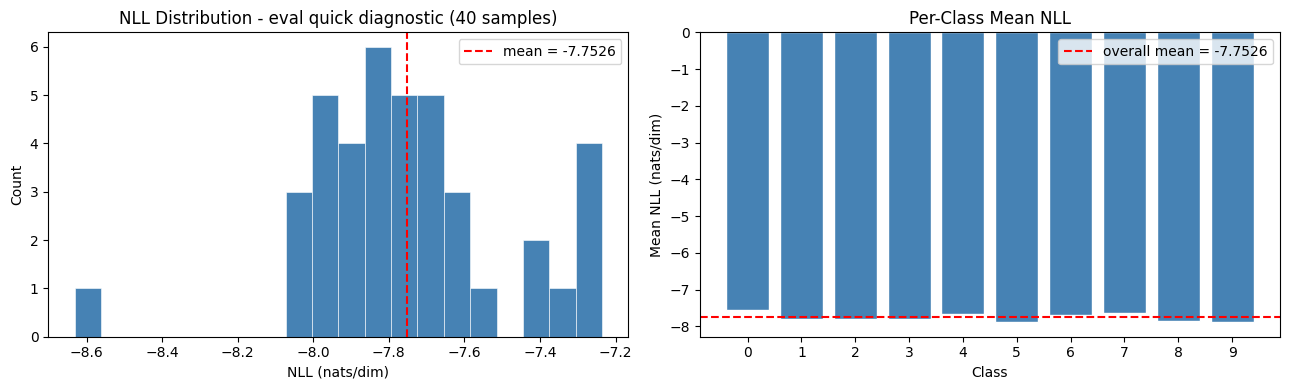

Saved -> results/figures/nll_distribution.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nll_arr, bins=min(20, max(8, nll_num_samples // 2)), edgecolor="white", linewidth=0.4, color="steelblue")
axes[0].axvline(nll_arr.mean(), color="red", linestyle="--", label=f"mean = {nll_arr.mean():.4f}")
axes[0].set_xlabel("NLL (nats/dim)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"NLL Distribution - {NLL_SPLIT_NAME} quick diagnostic ({nll_num_samples} samples)")
axes[0].legend()

class_mean_nll = [np.mean(class_nlls[c]) if len(class_nlls[c]) > 0 else np.nan for c in range(NUM_CLASSES)]
axes[1].bar(range(NUM_CLASSES), class_mean_nll, color="steelblue", edgecolor="white")
axes[1].axhline(nll_arr.mean(), color="red", linestyle="--", label=f"overall mean = {nll_arr.mean():.4f}")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Mean NLL (nats/dim)")
axes[1].set_title("Per-Class Mean NLL")
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/nll_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> results/figures/nll_distribution.png")

## 3. Latent Space Normality

If the flow has learned a good mapping to the standard Gaussian prior, scalar entries in
`z_list` should look approximately like samples from `N(0, 1)`.

This check uses **global min-max normalized** inputs matching the checkpoint.
We encode a small balanced batch of real images, aggregate latent values across scales and
spatial positions, then inspect:
- global mean and std
- Kolmogorov-Smirnov statistic vs `N(0, 1)`
- histogram with `N(0, 1)` overlay
- Q-Q plot

Important: with very large latent samples, the KS **p-value** becomes almost useless because it
will reject even small deviations from normality. The more informative signals here are:
- latent mean: should be close to `0`
- latent std: should be close to `1`
- KS statistic itself: smaller is better

For this checkpoint, the main issue is usually a **std below 1**, meaning the encoded latents are
slightly too concentrated compared with the ideal unit Gaussian prior.

In [29]:
LATENT_SAMPLES_PER_CLASS = 1
latent_entries = select_balanced_entries(EVAL_ENTRIES, LATENT_SAMPLES_PER_CLASS)
x_batch, lbl_batch = load_entry_batch(latent_entries)

with torch.no_grad():
    z_list_batch, _ = model(x_batch, lbl_batch)

z_all = np.concatenate([z.cpu().numpy().ravel() for z in z_list_batch])
latent_mean = float(z_all.mean())
latent_std = float(z_all.std())

print(f"Latent diagnostic on {len(latent_entries)} eval samples ({LATENT_SAMPLES_PER_CLASS} per class)")
print(f"Total latent values: {len(z_all):,}")
print(f"  mean = {latent_mean:.4f}   (expect ~0)")
print(f"  std  = {latent_std:.4f}   (expect ~1)")

rng = np.random.default_rng(0)
ks_sample_size = min(50_000, len(z_all))
sample = rng.choice(z_all, size=ks_sample_size, replace=False)
ks_stat, ks_pval = spst.kstest(sample, "norm")
print(f"\nKS test vs N(0,1) on {ks_sample_size:,} sampled latents: stat = {ks_stat:.4f},  p = {ks_pval:.4e}")

mean_gap = abs(latent_mean)
std_gap = abs(latent_std - 1.0)
print("\nInterpretation:")
if mean_gap < 0.05 and std_gap < 0.05 and ks_stat < 0.02:
    print("  Latent distribution is very close to the unit Gaussian prior.")
elif mean_gap < 0.05 and std_gap < 0.15 and ks_stat < 0.06:
    print("  Latent distribution is reasonably close to N(0,1), but not perfect.")
    print("  The main deviation is mild scale mismatch rather than a mean shift.")
else:
    print("  Latent distribution deviates materially from N(0,1).")
    if std_gap >= 0.15:
        print("  The largest issue is variance mismatch: latents are too narrow or too wide.")
    if mean_gap >= 0.05:
        print("  There is also a noticeable mean shift away from zero.")

print(f"  |mean| gap = {mean_gap:.4f}")
print(f"  |std-1| gap = {std_gap:.4f}")

Latent diagnostic on 10 eval samples (1 per class)
Total latent values: 20,480,000
  mean = -0.0078   (expect ~0)
  std  = 0.8973   (expect ~1)

KS test vs N(0,1) on 50,000 sampled latents: stat = 0.0447,  p = 0.0000e+00

Interpretation:
  Latent distribution is reasonably close to N(0,1), but not perfect.
  The main deviation is mild scale mismatch rather than a mean shift.
  |mean| gap = 0.0078
  |std-1| gap = 0.1027


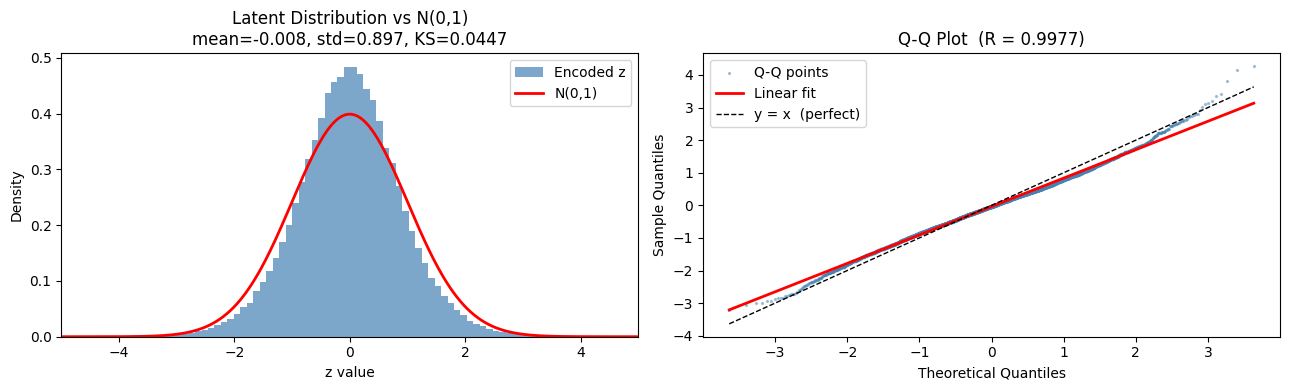

Saved → results/figures/latent_normality.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram vs N(0,1) ---
plot_sample = rng.choice(z_all, size=min(200_000, len(z_all)), replace=False)
axes[0].hist(plot_sample, bins=120, density=True, alpha=0.7,
             color="steelblue", edgecolor="none", label="Encoded z")
xv = np.linspace(-5, 5, 500)
axes[0].plot(xv, spst.norm.pdf(xv), "r-", lw=2, label="N(0,1)")
axes[0].set_xlim(-5, 5)
axes[0].set_xlabel("z value")
axes[0].set_ylabel("Density")
axes[0].set_title(
    f"Latent Distribution vs N(0,1)\n"
    f"mean={z_all.mean():.3f}, std={z_all.std():.3f}, "
    f"KS={ks_stat:.4f}"
)
axes[0].legend()

# --- Q-Q plot (5k points for legibility) ---
qq_sample = rng.choice(z_all, size=5000, replace=False)
(osm, osr), (slope, intercept, r) = spst.probplot(qq_sample, dist="norm", fit=True)
axes[1].scatter(osm, osr, s=2, alpha=0.4, color="steelblue", label="Q-Q points")
line_x = np.array([osm[0], osm[-1]])
axes[1].plot(line_x, slope * line_x + intercept, "r-", lw=2, label="Linear fit")
axes[1].plot(line_x, line_x, "k--", lw=1, label="y = x  (perfect)")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")
axes[1].set_title(f"Q-Q Plot  (R = {r:.4f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/latent_normality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/latent_normality.png")

## 4. Maximum Mean Discrepancy (MMD)

MMD with an RBF kernel measures the distance between two distributions in a reproducing
kernel Hilbert space — a model-agnostic alternative to FID that works directly in
spectral/pixel space rather than learned feature space.

**Feature representation:** mean spectrum per image → (N, 125) vectors.  
Spatial averaging compresses each 128×128×125 image to a 125-dim spectral signature,
capturing per-band brightness distribution mismatches.  
**Kernel:** RBF with γ set by the median-distance heuristic on the pooled real+generated set.

In [31]:
from sklearn.metrics.pairwise import euclidean_distances

# Load global stats for normalizing raw uint16 images to [0,1]
_stats     = np.load(STATS_NPZ)
_gmin      = float(_stats["global_min"])
_gscale    = float(_stats["global_max"]) - _gmin


def load_imgs_to_01(file_list: list) -> list:
    """Load .npy (uint16, HWC) and normalize to [0,1] using global stats."""
    imgs = []
    for p in file_list:
        arr = np.load(p).astype(np.float32)
        arr = (arr - _gmin) / (_gscale + 1e-8)
        imgs.append(arr)
    return imgs


def mean_spectra(images: list) -> np.ndarray:
    """Spatial mean spectrum per image: list of (H,W,125) → (N,125)."""
    return np.stack([img.reshape(-1, img.shape[-1]).mean(0) for img in images])


def compute_mmd(X: np.ndarray, Y: np.ndarray) -> float:
    """Unbiased RBF-kernel MMD with median-heuristic gamma."""
    all_data  = np.vstack([X, Y])
    D         = euclidean_distances(all_data)
    med_dist  = np.median(D[D > 0])
    gamma     = 1.0 / (2.0 * med_dist ** 2 + 1e-8)

    K_XX = rbf_kernel(X, X, gamma)
    K_XY = rbf_kernel(X, Y, gamma)
    K_YY = rbf_kernel(Y, Y, gamma)
    return float(K_XX.mean() + K_YY.mean() - 2.0 * K_XY.mean())

In [32]:
mmd_per_class = {}
n_real_per_class = {}

for cls in range(NUM_CLASSES):
    real_files = sorted(Path("../data/evaluation").joinpath(str(cls)).glob("*.npy"))
    gen_files  = sorted(GEN_DIR.joinpath(str(cls)).glob("*.npy"))

    # Match sample counts
    n = min(len(real_files), len(gen_files))
    real_imgs = load_imgs_to_01(real_files[:n])
    gen_imgs  = load_imgs_to_01(gen_files[:n])

    X_real = mean_spectra(real_imgs)  # (n, 125)
    X_gen  = mean_spectra(gen_imgs)   # (n, 125)

    mmd_val = compute_mmd(X_real, X_gen)
    mmd_per_class[cls]      = mmd_val
    n_real_per_class[cls]   = n
    print(f"Class {cls}: MMD = {mmd_val:.6f}  (N={n})")

mean_mmd = float(np.mean(list(mmd_per_class.values())))
print(f"\nMean MMD: {mean_mmd:.6f}")

Class 0: MMD = 0.695143  (N=50)
Class 1: MMD = 0.679343  (N=50)
Class 2: MMD = 0.672763  (N=50)
Class 3: MMD = 0.706628  (N=50)
Class 4: MMD = 0.709728  (N=50)
Class 5: MMD = 0.709521  (N=50)
Class 6: MMD = 0.738979  (N=50)
Class 7: MMD = 0.763235  (N=50)
Class 8: MMD = 0.737955  (N=50)
Class 9: MMD = 0.695251  (N=50)

Mean MMD: 0.710855


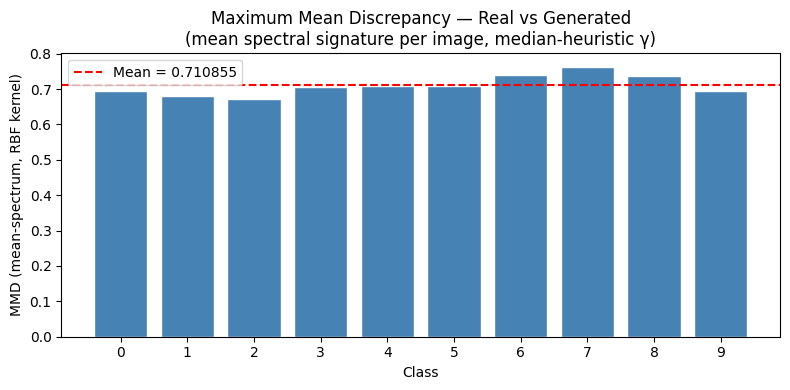

Saved → results/figures/mmd_per_class.png


In [33]:
plt.figure(figsize=(8, 4))
plt.bar(mmd_per_class.keys(), mmd_per_class.values(),
        color="steelblue", edgecolor="white")
plt.axhline(mean_mmd, color="red", linestyle="--",
            label=f"Mean = {mean_mmd:.6f}")
plt.xlabel("Class")
plt.ylabel("MMD (mean-spectrum, RBF kernel)")
plt.title("Maximum Mean Discrepancy — Real vs Generated\n"
          "(mean spectral signature per image, median-heuristic γ)")
plt.xticks(range(NUM_CLASSES))
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/mmd_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/mmd_per_class.png")

## 5. FID Scores (Competition Metric)

FID measures distributional similarity in InceptionV3 pool3 feature space
(SRF-projected to 3-channel Sentinel-2 bands before resizing to 299×299).  
Lower is better.  Best submission used temperature = 0.60.

Mean FID: 94.43


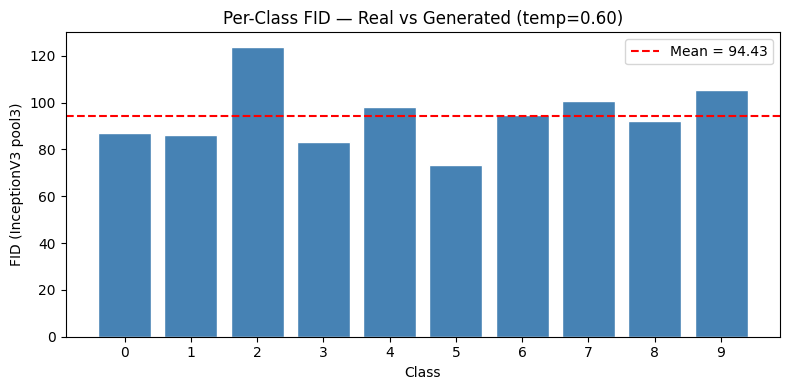

Saved → results/figures/fid_per_class.png


In [34]:
import csv

fid_rows = []
with open(SUBMISSION, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        fid_rows.append({"class": int(row["class"]),
                         "fid":   float(row["fid"]),
                         "temp":  float(row["temperature"])})

classes  = [r["class"] for r in fid_rows]
fid_vals = [r["fid"]   for r in fid_rows]
mean_fid = float(np.mean(fid_vals))
print(f"Mean FID: {mean_fid:.2f}")

plt.figure(figsize=(8, 4))
plt.bar(classes, fid_vals, color="steelblue", edgecolor="white")
plt.axhline(mean_fid, color="red", linestyle="--",
            label=f"Mean = {mean_fid:.2f}")
plt.xlabel("Class")
plt.ylabel("FID (InceptionV3 pool3)")
plt.title("Per-Class FID — Real vs Generated (temp=0.60)")
plt.xticks(classes)
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/fid_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/fid_per_class.png")

## 6. Summary

All diagnostic results for the epoch-125 checkpoint.

In [35]:
print("=" * 62)
print(f"{'Metric':<38} {'Value':>10}  {'Notes'}")
print("-" * 62)
print(f"{'Recon max error':<38} {recon_max:>10.2e}  global min-max inputs")
print(f"{'Recon mean error':<38} {recon_mean:>10.2e}  global min-max inputs")
print(f"{'Eval NLL - mean (nats/dim)':<38} {nll_arr.mean():>10.4f}  {nll_num_samples} samples")
print(f"{'Eval NLL - std  (nats/dim)':<38} {nll_arr.std():>10.4f}  {nll_elapsed:0.1f}s")
print(f"{'Latent z mean':<38} {z_all.mean():>10.4f}  expect ~0")
print(f"{'Latent z std':<38} {z_all.std():>10.4f}  expect ~1")
print(f"{'KS stat vs N(0,1)':<38} {ks_stat:>10.4f}")
print(f"{'KS p-value':<38} {ks_pval:>10.4e}")
print(f"{'Mean MMD (mean-spectrum, RBF)':<38} {mean_mmd:>10.6f}")
print(f"{'Mean FID (competition metric)':<38} {mean_fid:>10.2f}  temp=0.60")
print("=" * 62)

print("\nPer-class FID vs MMD:")
print(f"  {'Class':<6}  {'FID':>8}  {'MMD':>10}")
print(f"  {'-'*6}  {'--------':>8}  {'----------':>10}")
for cls in range(NUM_CLASSES):
    fid_v = fid_vals[cls] if cls < len(fid_vals) else float('nan')
    mmd_v = mmd_per_class.get(cls, float('nan'))
    print(f"  {cls:<6}  {fid_v:>8.2f}  {mmd_v:>10.6f}")
print(f"  {'Mean':<6}  {mean_fid:>8.2f}  {mean_mmd:>10.6f}")

Metric                                      Value  Notes
--------------------------------------------------------------
Recon max error                          4.09e-05  global min-max inputs
Recon mean error                         2.28e-06  global min-max inputs
Eval NLL - mean (nats/dim)                -7.7526  40 samples
Eval NLL - std  (nats/dim)                 0.2682  55.8s
Latent z mean                             -0.0078  expect ~0
Latent z std                               0.8973  expect ~1
KS stat vs N(0,1)                          0.0447
KS p-value                             0.0000e+00
Mean MMD (mean-spectrum, RBF)            0.710855
Mean FID (competition metric)               94.43  temp=0.60

Per-class FID vs MMD:
  Class        FID         MMD
  ------  --------  ----------
  0          86.99    0.695143
  1          85.99    0.679343
  2         123.79    0.672763
  3          83.28    0.706628
  4          97.93    0.709728
  5          73.45    0.709521
  6        